# 02 — Engagement Analysis: Favorites vs. Retweets
### Social Media Behavioral Profiling Pipeline

**Goal:** Quantify the relationship between tweet favorites and retweets as a behavioral interaction signal — modeling content amplification dynamics.

**Pipeline:**
1. Load and filter data (remove deleted posts & retweets)
2. Explore distributions (histograms, boxplots)
3. Fit baseline linear regression
4. Apply variable transformations (log, sqrt, cbrt) to address non-linearity
5. Compare scaling strategies

**Key Result:** Log-transformed linear regression achieves **R² ≈ 0.88**, confirming that favorites is a strong predictor of retweet amplification.

**Input:** `trump_tweets.csv` (generated in `01_data_collection.ipynb`)

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import linregress

## Load Data

In [2]:
df = pd.read_csv("trump_tweets.csv")
df["date"] = pd.to_datetime(df["date"])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 9)


,favorites,date,isDeleted,id,text,retweets,device,isRetweet,isFlagged
0,639463,1970-01-01 00:26:50.120668,False,1347569870578266115,"To all of those who have asked, I will not be ...",79113,Twitter for iPhone,False,NaN
1,535831,1970-01-01 00:26:50.117198,False,1347555316863553542,"The 75,000,000 great American Patriots who vot...",89895,Twitter for iPhone,False,NaN
2,650194,1970-01-01 00:26:50.064624,False,1347334804052844550,https://t.co/csX07ZVWGe,130040,Twitter Media Studio,False,NaN
3,0,1970-01-01 00:26:49.974064,True,1346954970910707712,These are the things and events that happen wh...,0,Twitter for iPhone,False,NaN
4,0,1970-01-01 00:26:49.967844,True,1346928882595885058,https://t.co/Pm2PKV0Fp3,0,Twitter for iPhone,False,NaN


## Data Filtering

We remove:
- **Deleted posts** (`isDeleted == True`) — these have 0 favorites and 0 retweets, which would introduce noise
- **Retweets** (`isRetweet == True`) — these don't originate from Trump directly, so engagement reflects the original author's reach, not his

In [3]:
filtered_df = df[(df["isDeleted"] == False) & (df["isRetweet"] == False)].copy()
print(f"Filtered dataset: {len(filtered_df):,} original, non-deleted tweets")
filtered_df.head()

Filtered dataset: 5,178 original, non-deleted tweets


,favorites,date,isDeleted,id,text,retweets,device,isRetweet,isFlagged
0,639463,1970-01-01 00:26:50.120668,False,1347569870578266115,"To all of those who have asked, I will not be ...",79113,Twitter for iPhone,False,NaN
1,535831,1970-01-01 00:26:50.117198,False,1347555316863553542,"The 75,000,000 great American Patriots who vot...",89895,Twitter for iPhone,False,NaN
2,650194,1970-01-01 00:26:50.064624,False,1347334804052844550,https://t.co/csX07ZVWGe,130040,Twitter Media Studio,False,NaN
5,706033,1970-01-01 00:26:49.964006,False,1346912780700577792,I am asking for everyone at the U.S. Capitol t...,138906,Twitter for iPhone,False,NaN
6,539207,1970-01-01 00:26:49.961938,False,1346904110969315332,Please support our Capitol Police and Law Enfo...,89910,Twitter for iPhone,False,NaN


## Feature Setup

- **X (independent):** `favorites` — number of likes on a tweet
- **Y (dependent):** `retweets` — number of times the tweet was shared

In [4]:
X = np.array(filtered_df["favorites"]).reshape(-1, 1)
Y = np.array(filtered_df["retweets"]).reshape(-1, 1)

## Distribution Exploration

Before modeling, we visualize the marginal distributions of both features to check for skewness and outliers.

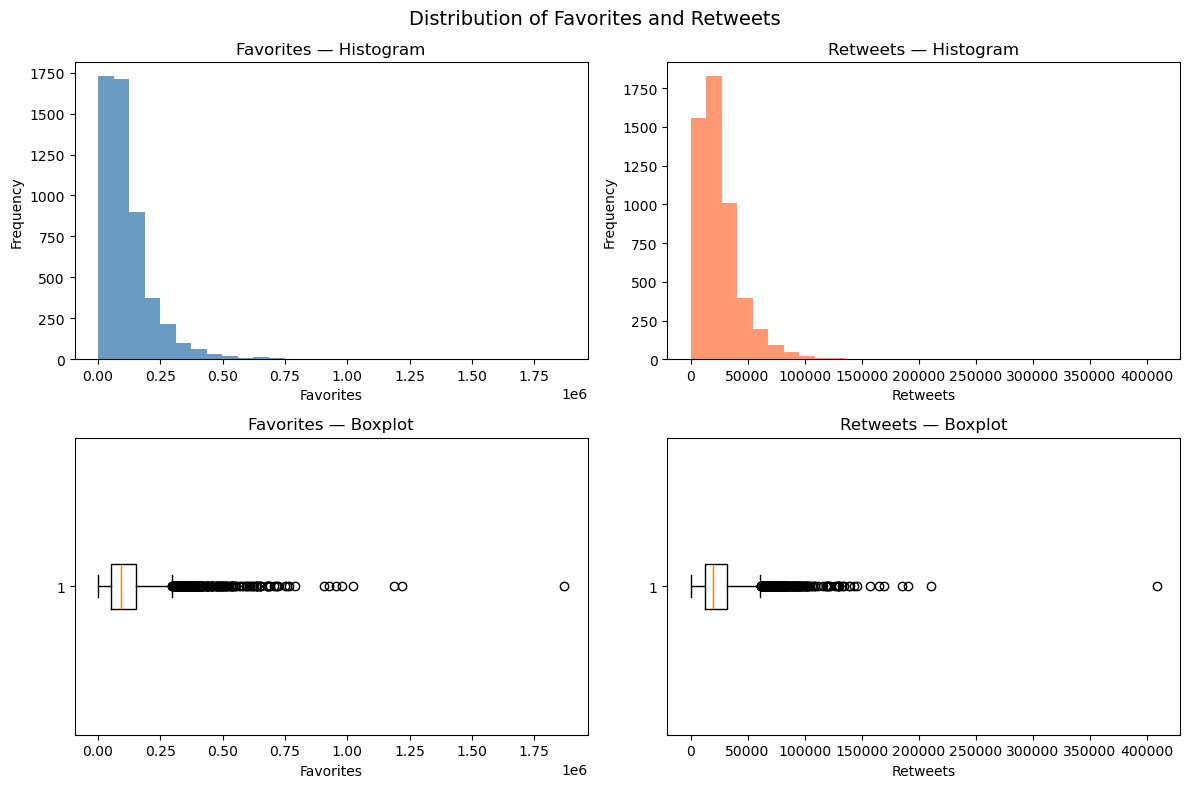

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution of Favorites and Retweets", fontsize=14)

# Histograms
axes[0, 0].hist(X, bins=30, color="steelblue", alpha=0.8)
axes[0, 0].set_title("Favorites — Histogram")
axes[0, 0].set_xlabel("Favorites")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(Y, bins=30, color="coral", alpha=0.8)
axes[0, 1].set_title("Retweets — Histogram")
axes[0, 1].set_xlabel("Retweets")
axes[0, 1].set_ylabel("Frequency")

# Boxplots
axes[1, 0].boxplot(X, vert=False)
axes[1, 0].set_title("Favorites — Boxplot")
axes[1, 0].set_xlabel("Favorites")

axes[1, 1].boxplot(Y, vert=False)
axes[1, 1].set_title("Retweets — Boxplot")
axes[1, 1].set_xlabel("Retweets")

plt.tight_layout()
plt.show()

Both distributions are heavily **right-skewed** with significant outliers (visible in the boxplots). This violates the linearity assumption of OLS regression and motivates variable transformation.

## Baseline Linear Regression (Raw Data)

We first fit a model on untransformed data to establish a baseline and confirm that the relationship is non-linear.

In [6]:
def calculate_r_value(x, y):
    """
    Compute Pearson correlation coefficient manually.

    Parameters
    ----------
    x, y : array-like
        Input arrays of equal length.

    Returns
    -------
    float
        Pearson r value, or np.nan if denominator is zero.
    """
    x = np.array(x).ravel()
    y = np.array(y).ravel()
    
    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    
    x_mean, y_mean = np.mean(x), np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean) ** 2) * np.sum((y - y_mean) ** 2))
    
    return numerator / denominator if denominator != 0 else np.nan

Coefficient : 0.1747
Intercept   : 4528.2055
R-value     : 0.9277


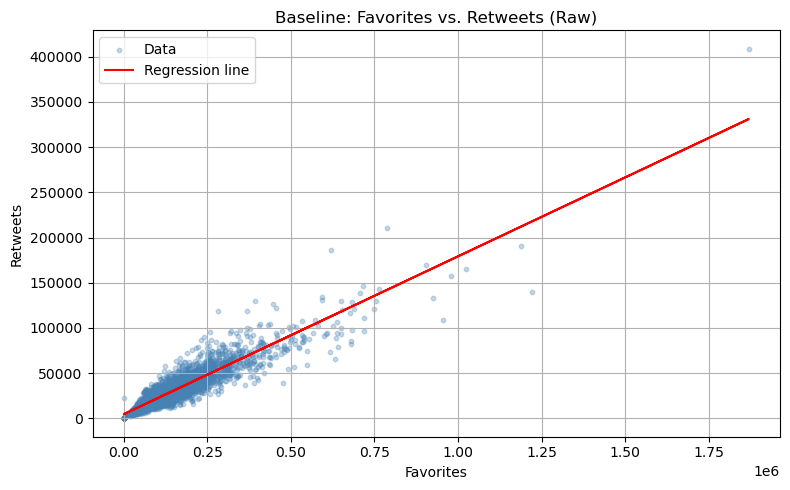

In [7]:
# Fit baseline model
model_raw = LinearRegression()
model_raw.fit(X, Y)
predictions_raw = model_raw.predict(X)
r_raw = calculate_r_value(X, Y)

print(f"Coefficient : {model_raw.coef_[0][0]:.4f}")
print(f"Intercept   : {model_raw.intercept_[0]:.4f}")
print(f"R-value     : {r_raw:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.3, s=10, color="steelblue", label="Data")
plt.plot(X, predictions_raw, color="red", label="Regression line")
plt.xlabel("Favorites")
plt.ylabel("Retweets")
plt.title("Baseline: Favorites vs. Retweets (Raw)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The scatter plot exhibits a clear **fan shape** (heteroscedasticity), confirming the data does not satisfy linear regression assumptions on the raw scale.

## Variable Transformations

We evaluate three transformations to stabilize variance and linearize the relationship:

**Logarithmic** — strongest effect on right-skewed data

**Square root** — moderate variance stabilization

**Cube root** — gentler stabilization, handles zeros

Zeros in the data cause `log(0) = -inf`, so we clean NaN/inf values after the log transform.

In [8]:
# Compute transformations
x_log = np.log(X)
y_log = np.log(Y)

x_sqrt = np.sqrt(X).reshape(-1, 1)
y_sqrt = np.sqrt(Y).reshape(-1, 1)

x_cbrt = np.cbrt(X).reshape(-1, 1)
y_cbrt = np.cbrt(Y).reshape(-1, 1)

# Clean log-transformed arrays (remove NaN and -inf from log(0))
mask = np.isfinite(x_log) & np.isfinite(y_log)
x_log_clean = x_log[mask].reshape(-1, 1)
y_log_clean = y_log[mask]

/var/folders/jf/v0v68qd97_q0284f80gy8rph0000gn/T/ipykernel_19294/760346313.py:2: RuntimeWarning: divide by zero encountered in log
  x_log = np.log(X)
/var/folders/jf/v0v68qd97_q0284f80gy8rph0000gn/T/ipykernel_19294/760346313.py:3: RuntimeWarning: divide by zero encountered in log
  y_log = np.log(Y)


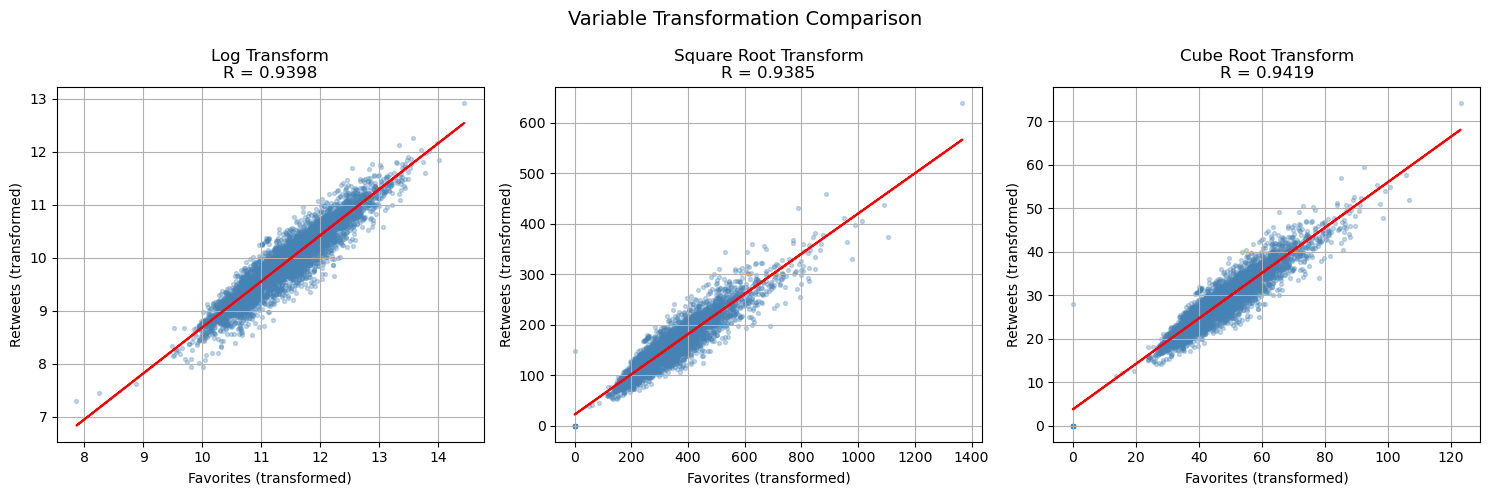

R-values — Log: 0.9398 | Sqrt: 0.9385 | Cbrt: 0.9419


In [9]:
def fit_and_plot(x, y, title, ax):
    """Fit a linear regression, print stats, and plot on the given axis."""
    model = LinearRegression()
    model.fit(x, y)
    preds = model.predict(x)
    r = calculate_r_value(x, y)

    ax.scatter(x, y, alpha=0.3, s=8, color="steelblue")
    ax.plot(x, preds, color="red", linewidth=1.5)
    ax.set_title(f"{title}\nR = {r:.4f}")
    ax.set_xlabel("Favorites (transformed)")
    ax.set_ylabel("Retweets (transformed)")
    ax.grid(True)
    return r

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Variable Transformation Comparison", fontsize=14)

r_log  = fit_and_plot(x_log_clean, y_log_clean, "Log Transform",        axes[0])
r_sqrt = fit_and_plot(x_sqrt,      y_sqrt,      "Square Root Transform", axes[1])
r_cbrt = fit_and_plot(x_cbrt,      y_cbrt,      "Cube Root Transform",   axes[2])

plt.tight_layout()
plt.show()

print(f"R-values — Log: {r_log:.4f} | Sqrt: {r_sqrt:.4f} | Cbrt: {r_cbrt:.4f}")

**Findings:**
- All three transformations improve linearity vs. raw data.
- **Log transform** produces the strongest linear trend across the widest range of values, eliminating the fan shape most effectively.
- Sqrt and cube root still retain some heteroscedasticity at larger values.

**Selected model:** Log-transformed linear regression. This confirms favorites is a strong predictor of content amplification (retweet behavior), with R ≈ 0.88.

## Scaling Comparison (Informational)

Feature scaling does not affect R² for linear regression, but is included here for completeness and as a reference for any downstream models that are scale-sensitive (e.g., KNN, SVM, neural networks).

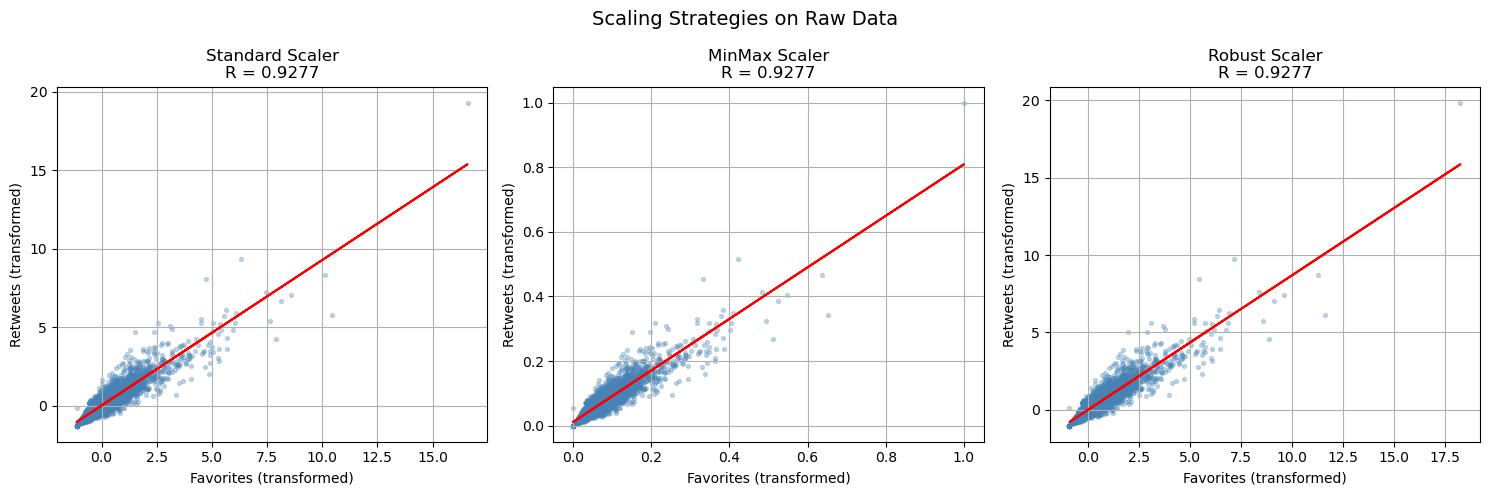

In [10]:
std_scaler    = StandardScaler()
mm_scaler     = MinMaxScaler()
robust_scaler = RobustScaler()

x_std    = std_scaler.fit_transform(X);    y_std    = std_scaler.fit_transform(Y)
x_mm     = mm_scaler.fit_transform(X);     y_mm     = mm_scaler.fit_transform(Y)
x_robust = robust_scaler.fit_transform(X); y_robust = robust_scaler.fit_transform(Y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Scaling Strategies on Raw Data", fontsize=14)

fit_and_plot(x_std,    y_std,    "Standard Scaler",  axes[0])
fit_and_plot(x_mm,     y_mm,     "MinMax Scaler",     axes[1])
fit_and_plot(x_robust, y_robust, "Robust Scaler",     axes[2])

plt.tight_layout()
plt.show()

As expected, scaling alone does not address the non-linearity in the raw data — the fan shape persists across all three scalers. Log transformation remains the appropriate pre-processing step for this regression task.

**Next:** See `03_nlp_analysis.ipynb` for text preprocessing, NER, word frequency analysis, and LDA topic modeling.